# Heikin-Ashi

The `HeikinAshi` primitive plots Heikin-Ashi ("average bar") candles — a `Candlesticks` specialization bound to the `calc_heikin_ashi` indicator. The calc computes in numpy and wraps the result back into the source backend via `wrap_result`, so the primitive works with both pandas and polars prices.


## Pandas backend


In [1]:
from mplchart.chart import Chart
from mplchart.samples import sample_prices
from mplchart.primitives import Candlesticks, HeikinAshi

prices = sample_prices(freq='daily')
prices.tail()


,open,high,low,close,volume
date,,,,,
2025-11-11,269.809998,275.910004,269.799988,275.250000,46208300
2025-11-12,275.000000,275.730011,271.700012,273.470001,48398000
2025-11-13,274.109985,276.700012,272.089996,272.950012,49602800
2025-11-14,271.049988,275.959991,269.600006,272.410004,47399300
2025-11-17,268.815002,270.489990,265.730011,267.459991,42862157


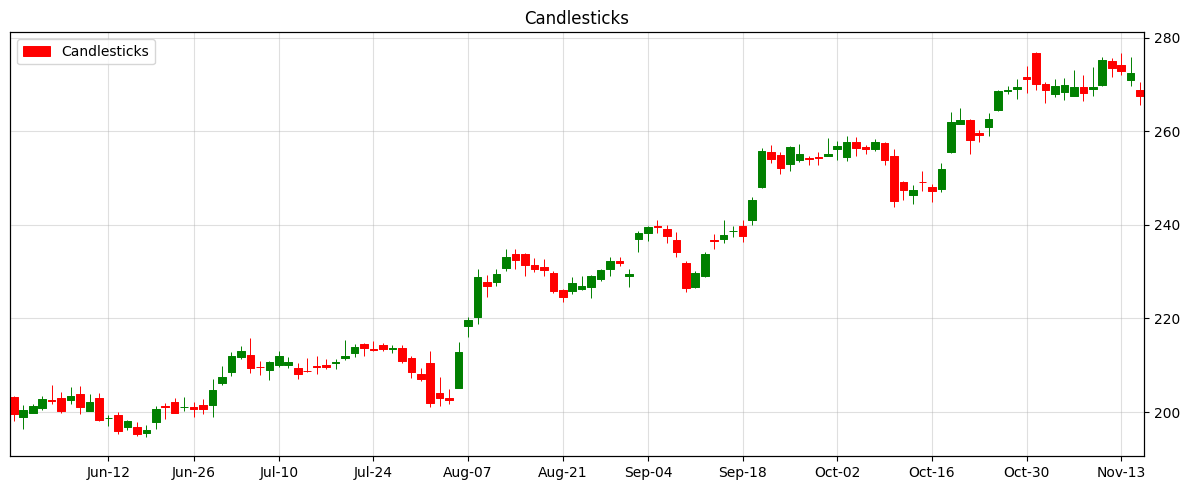

In [2]:
# regular candlesticks for comparison
Chart(prices, title='Candlesticks', max_bars=120, figsize=(12, 5)).plot(
    Candlesticks(colorup='green', colordn='red')
).show()


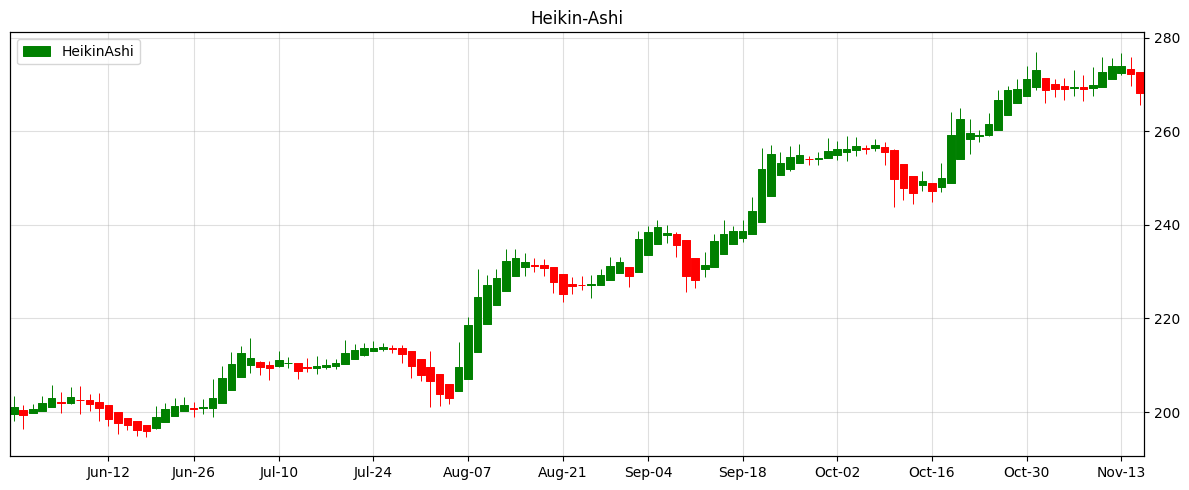

In [3]:
Chart(prices, title='Heikin-Ashi', max_bars=120, figsize=(12, 5)).plot(
    HeikinAshi(colorup='green', colordn='red')
).show()


The calc is usable on its own — frame in, frame out, same backend:


In [4]:
from mplchart.primitives.heikinashi import calc_heikin_ashi

calc_heikin_ashi(prices).tail()


,open,high,low,close
date,,,,
2025-11-11,269.567880,275.910004,269.567880,272.692497
2025-11-12,271.130189,275.730011,271.130189,273.975006
2025-11-13,272.552597,276.700012,272.089996,273.962502
2025-11-14,273.257549,275.959991,269.600006,272.254997
2025-11-17,272.756273,272.756273,265.730011,268.123749


## Polars backend


In [5]:
polars_prices = sample_prices(freq='daily', backend='polars')
polars_prices.tail()


date,open,high,low,close,volume
date,f64,f64,f64,f64,i64
2025-11-11,269.809998,275.910004,269.799988,275.25,46208300
2025-11-12,275.0,275.730011,271.700012,273.470001,48398000
2025-11-13,274.109985,276.700012,272.089996,272.950012,49602800
2025-11-14,271.049988,275.959991,269.600006,272.410004,47399300
2025-11-17,268.815002,270.48999,265.730011,267.459991,42862157


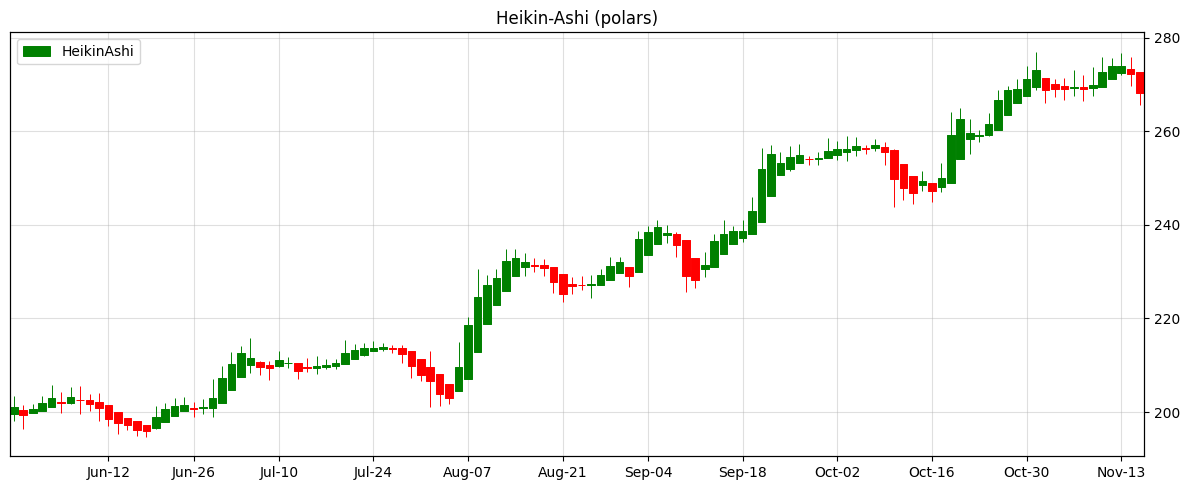

In [6]:
Chart(polars_prices, title='Heikin-Ashi (polars)', max_bars=120, figsize=(12, 5)).plot(
    HeikinAshi(colorup='green', colordn='red')
).show()


In [7]:
calc_heikin_ashi(polars_prices).tail()


open,high,low,close
f64,f64,f64,f64
269.56788,275.910004,269.56788,272.692497
271.130189,275.730011,271.130189,273.975006
272.552597,276.700012,272.089996,273.962502
273.257549,275.959991,269.600006,272.254997
272.756273,272.756273,265.730011,268.123749


## Styling

`HeikinAshi` accepts the `Candlesticks` styling arguments — color schemes, `candle.*` settings, hollow mode — except `use_prev_close`, which is pinned intrabar (Heikin-Ashi bars define their direction as ha close vs ha open).


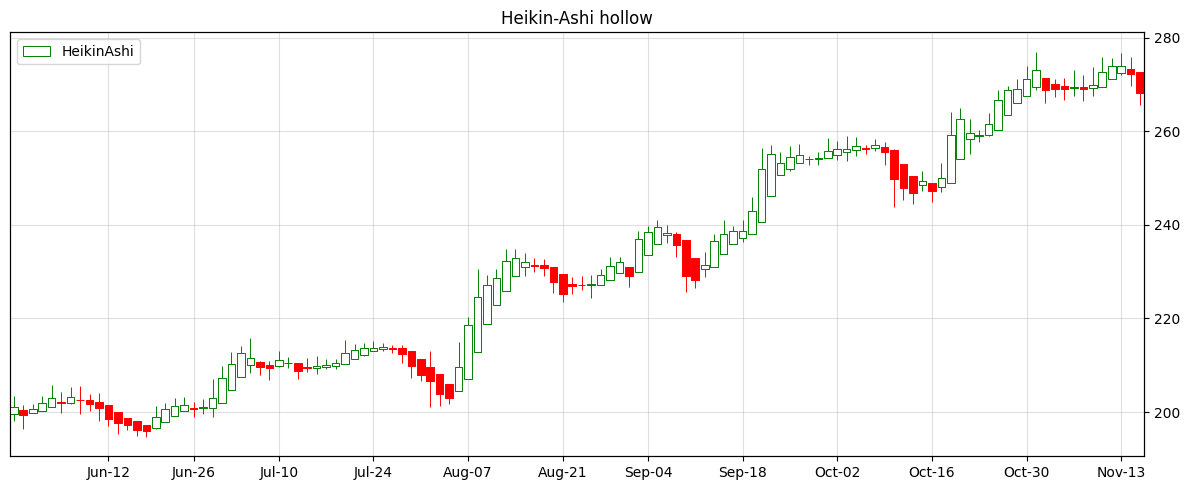

In [8]:
Chart(prices, title='Heikin-Ashi hollow', max_bars=120, figsize=(12, 5)).plot(
    HeikinAshi(colorup='green', colordn='red', hollow=True)
).show()
